# Part 1: Data Preparation

In [78]:
import pandas as pd

df = pd.read_csv('../KAG_energydata_complete.csv', index_col=0)
print(df.shape)
print(df.columns)
print(df.head(10))
df.info()

(19735, 28)
Index(['Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4',
       'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9',
       'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility',
       'Tdewpoint', 'rv1', 'rv2'],
      dtype='object')
                     Appliances  lights         T1       RH_1     T2  \
date                                                                   
2016-01-11 17:00:00          60      30  19.890000  47.596667  19.20   
2016-01-11 17:10:00          60      30  19.890000  46.693333  19.20   
2016-01-11 17:20:00          50      30  19.890000  46.300000  19.20   
2016-01-11 17:30:00          50      40  19.890000  46.066667  19.20   
2016-01-11 17:40:00          60      40  19.890000  46.333333  19.20   
2016-01-11 17:50:00          50      40  19.890000  46.026667  19.20   
2016-01-11 18:00:00          60      50  19.890000  45.766667  19.20   
2016-01-11 18:10:00          60      50  19.856667 

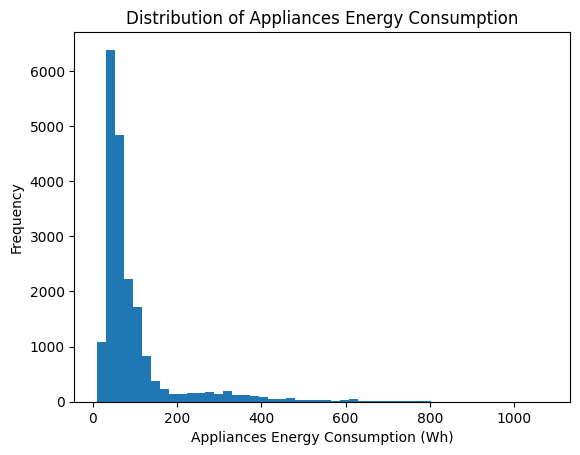

In [79]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df['Appliances'], bins=50)
plt.xlabel('Appliances Energy Consumption (Wh)')
plt.ylabel('Frequency')
plt.title('Distribution of Appliances Energy Consumption')
plt.show()

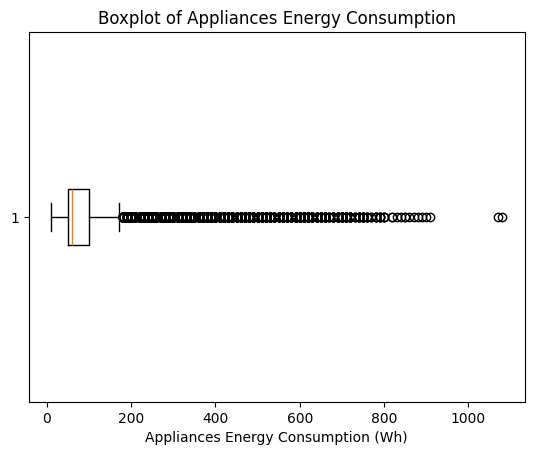

In [80]:
plt.figure()
plt.boxplot(df['Appliances'], vert=False)
plt.xlabel('Appliances Energy Consumption (Wh)')
plt.title('Boxplot of Appliances Energy Consumption')
plt.show()

According to the plots, the target variable exhibits a large number of extreme values, indicating the presence of high energy consumption spikes that should be explicitly considered in the modeling process.

# Part 2: Feature Engineering

Feature engineering for this time-series task focuses on lagged variables and rolling window statistics. This approach is dictated by the strong temporal dependencies inherent in energy consumption data, where future demand is highly autocorrelated with historical usage patterns.

## 1. Time features

In [81]:
import numpy as np

In [82]:
df = df.copy()
df.index = pd.to_datetime(df.index)

In [83]:
# extract basic time features
df['hour'] = df.index.hour
df['day_of_week'] = df.index.dayofweek  
df['month'] = df.index.month
df['day_of_month'] = df.index.day
df['day_of_year'] = df.index.dayofyear

In [84]:
# weekend or not
df['is_weekend'] = np.where(df.index.dayofweek >= 5, 'weekend', 'weekday')

In [85]:
conditions = [
    (df['hour'] >= 6) & (df['hour'] < 12),
    (df['hour'] >= 12) & (df['hour'] < 18),
    (df['hour'] >= 18) & (df['hour'] < 24)
]

choices = ['morning', 'afternoon', 'evening']

df['time_period'] = np.select(conditions, choices, default='night')


In [86]:
# to encode periodic time features

"""
In order to capture periodic patterns, we apply cyclical encoding using sine and cosine transformations. 
This converts discrete time units into continuous circular coordinates.
It maintains the proximity between adjacent periods and eliminating artificial discontinuities at period boundaries.

"""

# hour
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# week
df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

# month
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# day of month
df['day_of_month_sin'] = np.sin(2 * np.pi * df['day_of_month'] / 30)
df['day_of_month_cos'] = np.cos(2 * np.pi * df['day_of_month'] / 30)

# day of year
df['day_of_year_sin'] = np.sin(2 * np.pi * df['day_of_year'] / 366)
df['day_of_year_cos'] = np.cos(2 * np.pi * df['day_of_year'] / 366)

## 2. Temperature features

In [87]:
df["T_indoor_avg"] = df[df.filter(like='T').columns.drop('T6','T_out')].mean(axis=1) # average temperature of 8 rooms
df["T_indoor_std"] = df[df.filter(like='T').columns.drop('T6','T_out')].std(axis=1) # standard error of temperature of 8 rooms
df["T_indoor_max"] = df[df.filter(like='T').columns.drop('T6','T_out')].max(axis=1) # maximum temperature of 8 rooms
df["T_indoor_min"] = df[df.filter(like='T').columns.drop('T6','T_out')].min(axis=1) # minimum temperature of 8 rooms
df["T_indoor_range"] = df["T_indoor_max"] - df["T_indoor_min"] # the range of indoor temperature
df['T_indoor_change'] = df['T_indoor_avg'].diff() # change rate of indoor temperature

In [88]:
# the difference between indoor and outdoor temperatures
df["T_diff_1"] = df["T_indoor_avg"] - df["T6"]
df["T_diff_2"] = df["T_indoor_avg"] - df["T_out"]

## 3. Humidity features

In [89]:
df["RH_indoor_avg"] = df[df.filter(like='RH').columns.drop('RH_6','RH_out')].mean(axis=1) # average humidity of 8 rooms
df["RH_indoor_std"] = df[df.filter(like='RH').columns.drop('RH_6','RH_out')].std(axis=1) # standard error of humidity of 8 rooms
df["RH_indoor_max"] = df[df.filter(like='RH').columns.drop('RH_6','RH_out')].max(axis=1) # maximum humidity of 8 rooms
df["RH_indoor_min"] = df[df.filter(like='RH').columns.drop('RH_6','RH_out')].min(axis=1) # minimum humidity of 8 rooms
df["RH_indoor_range"] = df["RH_indoor_max"] - df["RH_indoor_min"] # the range of indoor humidity
df['RH_indoor_change'] = df['RH_indoor_avg'].diff() # change rate of indoor humidity

In [90]:
# the difference between indoor and outdoor humidity
df["RH_diff_1"] = df["RH_indoor_avg"] - df["RH_6"]
df["RH_diff_2"] = df["RH_indoor_avg"] - df["RH_out"]

In [91]:
pip install metpy

In [92]:
# comfort measures
import metpy.calc as mpcalc
from metpy.calc import heat_index
from metpy.units import units
temp = df["T_indoor_avg"].values * units.degC
humidity = df["RH_indoor_avg"].values * units.percent

# heat index
df["heat_index"] = heat_index(temp, humidity)

# dewpoint
df["dewpoint"] = mpcalc.dewpoint_from_relative_humidity(temp, humidity)

## 4. Weather measures

In [93]:
# weather comprehensive measure
df["weather_com"] = df["T_out"].values * df["RH_out"].values *0.01 * df["Windspeed"].values

In [94]:
# change rate
df['T6_change'] = df['T6'].diff()
df['T_out_change'] = df['T_out'].diff()
df['RH_6_change'] = df['RH_6'].diff()
df['RH_out_change'] = df['RH_out'].diff()
df['Press_change'] = df['Press_mm_hg'].diff()
df['Windspeed_change'] = df['Windspeed'].diff()

## 5. Lag features (without target)

In [95]:
# lights lag
df['lights_lag1'] = df['lights'].shift(1)  
df['lights_lag2'] = df['lights'].shift(2)  
df['lights_lag3'] = df['lights'].shift(3)
df['lights_lag4'] = df['lights'].shift(6)
df['lights_lag5'] = df['lights'].shift(144)

In [96]:
# weather lag
df['T_indoor_lag1'] = df['T_indoor_avg'].shift(1)
df['T_indoor_lag6'] = df['T_indoor_avg'].shift(6)

df['T_out_lag1'] = df['T_out'].shift(1)
df['T_out_lag6'] = df['T_out'].shift(6)

## 6. Rolling features (without target)

In [97]:
# lights rolling
df['lights_rolling_mean_3'] = df['lights'].rolling(window=3, min_periods=1).mean()
df['lights_rolling_mean_6'] = df['lights'].rolling(window=6, min_periods=1).mean()
df['lights_rolling_mean_12'] = df['lights'].rolling(window=12, min_periods=1).mean()
df['lights_rolling_mean_18'] = df['lights'].rolling(window=18, min_periods=1).mean()
df['lights_rolling_max_6'] = df['lights'].rolling(window=6, min_periods=1).max()
df['lights_rolling_min_6'] = df['lights'].rolling(window=6, min_periods=1).min()
df['lights_rolling_std_18'] = df['lights'].rolling(window=18, min_periods=1).std()
df['lights_rolling_std_36'] = df['lights'].rolling(window=36, min_periods=1).std()

In [98]:
# weather rolling
df['T_indoor_rolling_mean_6'] = df['T_indoor_avg'].rolling(window=6, min_periods=1).mean()
df['T_indoor_rolling_max_6'] = df['T_indoor_avg'].rolling(window=6, min_periods=1).max()
df['T_indoor_rolling_min_6'] = df['T_indoor_avg'].rolling(window=6, min_periods=1).min()
df['T_indoor_rolling_std_6'] = df['T_indoor_avg'].rolling(window=6, min_periods=1).std()

df['T_out_rolling_mean_6'] = df['T_out'].rolling(window=6, min_periods=1).mean()
df['T_out_rolling_std_6'] = df['T_out'].rolling(window=6, min_periods=1).std()

## 7. Target variable rolling/lag

In [99]:
# split train and test dataset
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Appliances"]) 
y = np.log1p(df["Appliances"])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [100]:
# appliance lag
target_col = 'Appliances'

X_train[f'{target_col}_lag1']   = y_train.shift(1)
X_train[f'{target_col}_lag2']   = y_train.shift(2)
X_train[f'{target_col}_lag3']   = y_train.shift(3)
X_train[f'{target_col}_lag6']   = y_train.shift(6)
X_train[f'{target_col}_lag144'] = y_train.shift(144)

valid_idx = X_train.dropna().index
X_train = X_train.loc[valid_idx]
y_train = y_train.loc[valid_idx]

In [101]:
# appliance rolling
X_train[f'{target_col}_rolling_mean_3']  = y_train.rolling(3,  min_periods=1).mean().shift(1)
X_train[f'{target_col}_rolling_mean_6']  = y_train.rolling(6,  min_periods=1).mean().shift(1)
X_train[f'{target_col}_rolling_mean_12'] = y_train.rolling(12, min_periods=1).mean().shift(1)
X_train[f'{target_col}_rolling_mean_18'] = y_train.rolling(18, min_periods=1).mean().shift(1)

X_train[f'{target_col}_rolling_max_6'] = y_train.rolling(6, min_periods=1).max().shift(1)
X_train[f'{target_col}_rolling_min_6'] = y_train.rolling(6, min_periods=1).min().shift(1)

X_train[f'{target_col}_rolling_std_18'] = y_train.rolling(18, min_periods=1).std().shift(1)
X_train[f'{target_col}_rolling_std_36'] = y_train.rolling(36, min_periods=1).std().shift(1)

X_train[f'{target_col}_rolling_range_6'] = (
    y_train.rolling(6, min_periods=1).max()
    - y_train.rolling(6, min_periods=1).min()
).shift(1)

X_train[f'{target_col}_diff_1'] = y_train.diff(1).shift(1)

valid_idx = X_train.dropna().index
X_train = X_train.loc[valid_idx]
y_train = y_train.loc[valid_idx]

# Part 3: Feature Analysis

In [102]:
train_df = X_train.copy()
train_df["Appliances"] = y_train

In [103]:
# correlation-based feature selection
numeric_cols = train_df.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = train_df[numeric_cols].corr()
corr_with_target = corr_matrix[target_col].drop(target_col, errors='ignore')

k = 60
top_k = corr_with_target.abs().sort_values(ascending=False)[:k].index

selected_target_corr = corr_with_target[top_k].sort_values(ascending=False)
for i, (feature, corr) in enumerate(selected_target_corr.items(), 1):
    sign = "+" if corr > 0 else "-"
    print(f"{i:2d}. {feature:35s}: {corr:7.4f} ({sign})")

 1. Appliances_lag1                    :  0.8335 (+)
 2. Appliances_rolling_mean_3          :  0.7697 (+)
 3. Appliances_rolling_mean_6          :  0.7206 (+)
 4. Appliances_rolling_max_6           :  0.7188 (+)
 5. Appliances_lag2                    :  0.6988 (+)
 6. Appliances_rolling_mean_12         :  0.6810 (+)
 7. Appliances_rolling_mean_18         :  0.6317 (+)
 8. Appliances_rolling_min_6           :  0.6190 (+)
 9. Appliances_lag3                    :  0.6078 (+)
10. Appliances_lag6                    :  0.5039 (+)
11. Appliances_rolling_std_18          :  0.4760 (+)
12. Appliances_rolling_range_6         :  0.4106 (+)
13. Appliances_rolling_std_36          :  0.3818 (+)
14. Appliances_lag144                  :  0.3564 (+)
15. lights_rolling_max_6               :  0.3113 (+)
16. lights_rolling_mean_3              :  0.3018 (+)
17. lights                             :  0.2891 (+)
18. lights_rolling_mean_6              :  0.2861 (+)
19. lights_lag1                        :  0.27

1. The strong correlation between the target variable and its lagged and rolling statistics indicates autocorrelation, which is consistent with the persistent nature of residential appliance usage.  
2. "Lights" feature is a behavorial proxy rather than a main driver as its correlation score is not high.

In [104]:
# Bottom correlation features
all_correlations = corr_with_target.abs().sort_values(ascending=False)
print(all_correlations.tail(20))

day_of_month_cos    0.058687
RH_indoor_change    0.055581
day_of_year_cos     0.052351
day_of_month_sin    0.051309
dewpoint            0.047572
Windspeed_change    0.046524
Tdewpoint           0.046503
day_of_week_cos     0.042644
T_indoor_std        0.035043
day_of_week_sin     0.033620
T6_change           0.030296
RH_4                0.024503
RH_out_change       0.022406
RH_6_change         0.019527
Visibility          0.014546
RH_5                0.011519
T_out_change        0.008044
rv2                 0.005528
rv1                 0.005528
RH_3                0.001637
Name: Appliances, dtype: float64


AS the correlation results between rv1/rv2 and the target are approximately zero, we can delete these two random variables.

In [105]:
X_train = X_train.drop(columns=["rv1","rv2"]) 

# Part 4: Train model

Model Optimization & Selection
* feature selection
    * Phase 1: Classification
        * Categorized raw features into functional groups(e.g., indoor, outdoor, Lagging/Rolling)
    * Phase 2: Dimensionality Reduction (SHAP-RFE)
        * Pruned the feature space by selecting the top 50% using SHAP-based Recursive Feature Elimination.
    * Phase 3: Permutation Feature Importance (PFI)
        * Ranked the remaining candidates by calculating PFI scores to quantify their predictive impact.
    * Phase 4: Optimal Subset Determination
        * Executed **Expanding Window CV** on the validation set.
        * Identified the best feature set by minimizing the **RMSE** across multiple time-shifted folds.
* Hyperparameter Tuning
    * **Training Framework**: Utilized the Aggregated Development Set (Sub-train + Validation data).
    * **Optimization Algorithm**: Implemented Randomized Search to efficiently explore the high-dimensional parameter space.
    * **Validation Method**: Applied Expanding Window Cross-Validation to ensure the selected parameters are robust and respect temporal ordering.


## 1. Classify features into different groups

In [106]:
import re

In [107]:
all_features = X_train.columns  

feature_categories = {
    'Lights': [f for f in all_features if 'lights' in f],

    'Appliances': [f for f in all_features if f.startswith('Appliances_')],

    'Indoor': [
        f for f in all_features
        if (
        (
            f.startswith('T_indoor')
            or f.startswith('RH_indoor')
            or re.fullmatch(r'T\d+', f)         
            or re.fullmatch(r'RH_\d+', f)        
            or f == 'dewpoint'
        )
        and f not in ['T6', 'RH_6']
        and ('rolling' not in f and 'lag' not in f)
    )
    ],

    'Outdoor/Weather': [
        f for f in all_features if f in [
            'T_out', 'RH_out', 'Press_mm_hg', 'Press_change',
            'Windspeed', 'Windspeed_change', 'Visibility',
            'Tdewpoint', 'heat_index', 'weather_com'
        ]
    ],

    'Time': [
        f for f in all_features if f in [
            'hour', 'day_of_week', 'month', 'day_of_month', 'day_of_year',
            'is_weekend', 'time_period',
            'hour_sin', 'hour_cos',
            'day_of_week_sin', 'day_of_week_cos',
            'month_sin', 'month_cos',
            'day_of_month_sin', 'day_of_month_cos',
            'day_of_year_sin', 'day_of_year_cos'
        ]
    ],

    'lagging/rolling': [
        f for f in all_features
        if (
            ('lag' in f or 'rolling' in f)
            and not f.startswith('Appliances_')
            and 'lights' not in f
        )
    ]
}

outdoor_features = [
    'T6', 'RH_6',
    'T_diff_1', 'T_diff_2',
    'RH_diff_1', 'RH_diff_2',
    'T_out_change', 'T6_change',
    'RH_6_change', 'RH_out_change'
]

feature_categories['Outdoor/Weather'].extend(
    [f for f in outdoor_features if f in all_features]
)

for cat, feats in feature_categories.items():
    print(f"{cat}: {len(feats)} features")


Lights: 14 features
Appliances: 15 features
Indoor: 29 features
Outdoor/Weather: 20 features
Time: 17 features
lagging/rolling: 10 features


The purpose of classifying features into different groups is to achieve a balanced feature selection.

## 2. feature selection

In [108]:
# split the validation dataset
X_train_sub, X_val, y_train_sub, y_val = train_test_split(X_train, y_train, test_size=0.2, shuffle=False)

In [109]:
from catboost import CatBoostRegressor

In [110]:
X_train['is_weekend'] = X_train['is_weekend'].astype('category')
X_train['time_period'] = X_train['time_period'].astype('category')


Since CatBoost handles categorical features effectively, I intentionally treat these two variables as categorical features. They are always included in the feature sets to train the final model.

In [111]:
model_cat = CatBoostRegressor(
    cat_features = ['is_weekend', 'time_period'],
    iterations=1000,
    depth=6,
    learning_rate=0.05,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    verbose=False
)
model_cat.fit(X_train_sub, y_train_sub)

In [112]:
#select features using CatBoost’s SHAP-based recursive feature selection
sorted_group_names = sorted(feature_categories.keys())
selected_features_by_category = {}
all_selected_features_list = []

for group_name, features in feature_categories.items():
    features = feature_categories[group_name]
    num_to_select = max(1, len(features) // 2)  # Select half of the features in each group
    selected = model_cat.select_features(
        X=X_train_sub,
        y=y_train_sub,
        features_for_select=features,
        num_features_to_select=num_to_select,  
        algorithm='RecursiveByShapValues',
        steps=4,
        train_final_model=False,
        logging_level='Silent'
    )

    current_selected_names = [
        X_train.columns[f] if isinstance(f, int) else f 
        for f in selected['selected_features']
    ]

    unique_feats = []
    for f_name in current_selected_names:
        if f_name not in all_selected_features_list:
            unique_feats.append(f_name)
            all_selected_features_list.append(f_name)
            
    selected_features_by_category[group_name] = unique_feats

selected_features_by_category_names = {}
for group_name in sorted_group_names:
    selected_features_by_category_names[group_name] = selected_features_by_category[group_name]

for category in sorted_group_names:
    feat_names = selected_features_by_category_names[category]
    print(f"{category}: {feat_names}")

Appliances: ['Appliances_diff_1', 'Appliances_lag1', 'Appliances_rolling_mean_3', 'Appliances_rolling_mean_6', 'Appliances_rolling_mean_12', 'Appliances_rolling_mean_18', 'Appliances_rolling_max_6']
Indoor: ['dewpoint', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'T8', 'RH_8', 'T_indoor_range', 'T_indoor_change', 'RH_indoor_avg', 'RH_indoor_change']
Lights: ['lights', 'lights_lag5', 'lights_rolling_mean_3', 'lights_rolling_mean_6', 'lights_rolling_mean_18', 'lights_rolling_std_18', 'lights_rolling_std_36']
Outdoor/Weather: ['T6_change', 'T_out_change', 'RH_6_change', 'RH_out_change', 'Press_change', 'Windspeed_change', 'Press_mm_hg', 'Visibility', 'RH_diff_1', 'RH_diff_2']
Time: ['day_of_week_sin', 'day_of_month_cos', 'day_of_year_cos', 'hour', 'day_of_week', 'day_of_year', 'hour_sin', 'hour_cos']
lagging/rolling: ['T_indoor_rolling_std_6', 'T_out_rolling_mean_6', 'T_out_rolling_std_6', 'T_indoor_lag1', 'T_out_lag6']


In [113]:
selected_feature_names_cat = []
mandatory_features = ['is_weekend', 'time_period']

sorted_keys = sorted(selected_features_by_category_names.keys())

for category in sorted_keys:
    feat_names = selected_features_by_category_names[category]
    selected_feature_names_cat.extend(feat_names)

for f in mandatory_features:
    if f in X_train_sub.columns and f not in selected_feature_names_cat:
        selected_feature_names_cat.append(f)

X_train_sub_selected_features = X_train_sub[selected_feature_names_cat]
model_cat.fit(X_train_sub_selected_features,
              y_train_sub)


In [114]:
# final feature selection using permutation importance
# calculate pfi
from sklearn.inspection import permutation_importance
pfi_result = permutation_importance(
    model_cat, 
    X_train_sub_selected_features, 
    y_train_sub, 
    n_repeats=15,  
    random_state=42,
    scoring='neg_root_mean_squared_error'  
)
feature_importance_df = pd.DataFrame({
    'feature': X_train_sub_selected_features.columns,
    'importance': pfi_result.importances_mean
}).sort_values(by=['importance', 'feature'], ascending=[False, True])

print("PFI ranking of SHAP-selected features:")
print(feature_importance_df)


PFI ranking of SHAP-selected features:
                       feature  importance
1              Appliances_lag1    0.333619
0            Appliances_diff_1    0.039332
3    Appliances_rolling_mean_6    0.026729
6     Appliances_rolling_max_6    0.026695
2    Appliances_rolling_mean_3    0.024885
21                      lights    0.021240
4   Appliances_rolling_mean_12    0.020864
5   Appliances_rolling_mean_18    0.015606
45                    hour_cos    0.012346
44                    hour_sin    0.009987
28                   T6_change    0.009252
9                         RH_1    0.008236
11                        RH_2    0.007543
20            RH_indoor_change    0.007347
18             T_indoor_change    0.007081
14                          T4    0.006726
46      T_indoor_rolling_std_6    0.006501
34                 Press_mm_hg    0.006488
13                        RH_3    0.006484
15                          T8    0.005536
17              T_indoor_range    0.005501
35             

In [115]:
# PFI importance ranking by category
pfi_by_category = {}
sorted_categories = sorted(selected_features_by_category_names.keys())

for category, feat_names in selected_features_by_category_names.items():
    feat_names = selected_features_by_category_names[category]
    df_cat = feature_importance_df[
        feature_importance_df['feature'].isin(feat_names)
    ].sort_values(by=['importance', 'feature'], ascending=[False, True])

    pfi_by_category[category] = df_cat

for category, df_cat in pfi_by_category.items():
    df_cat = pfi_by_category[category]
    print(f"\nCategory: {category}")
    print(df_cat)


Category: Appliances
                      feature  importance
1             Appliances_lag1    0.333619
0           Appliances_diff_1    0.039332
3   Appliances_rolling_mean_6    0.026729
6    Appliances_rolling_max_6    0.026695
2   Appliances_rolling_mean_3    0.024885
4  Appliances_rolling_mean_12    0.020864
5  Appliances_rolling_mean_18    0.015606

Category: Indoor
             feature  importance
9               RH_1    0.008236
11              RH_2    0.007543
20  RH_indoor_change    0.007347
18   T_indoor_change    0.007081
14                T4    0.006726
13              RH_3    0.006484
15                T8    0.005536
17    T_indoor_range    0.005501
16              RH_8    0.004611
19     RH_indoor_avg    0.004131
12                T3    0.003766
8                 T1    0.003366
7           dewpoint    0.002827
10                T2    0.002386

Category: Lights
                   feature  importance
21                  lights    0.021240
24   lights_rolling_mean_6    0.0

In [116]:
X_val.shape

(3129, 105)

In [117]:
# select best feature sets for final model training and hyperparameter tuning
# using expanding window cv on validation datasets
# metric: RMSE
from sklearn.metrics import mean_squared_error

# categorical features
cat_features = ['is_weekend', 'time_period']

# validation parameters
validation_window = 1008  
expanding_step = 336      
metric = mean_squared_error

# top_k per category
top_k_per_category = {
    'Lights': 2,
    'Appliances': 4,
    'Indoor': 4,
    'Outdoor/Weather': 3,
    'Time': 2,
    'lagging/rolling': 3
}

# Step 1: build base features (mandatory + top-K per category)
base_features = mandatory_features.copy()
for cat in sorted_categories:
    df = pfi_by_category[cat]
    k = top_k_per_category.get(cat, len(df))
    top_feats = df['feature'].tolist()[:k]
    for f in top_feats:
        if f not in base_features:
            base_features.append(f)

# Step 2: build remaining features sorted by global PFI
all_features_sorted = []
for cat in sorted_categories:
    all_features_sorted.extend(pfi_by_category[cat]['feature'].tolist())
    
remaining_features = [f for f in all_features_sorted if f not in base_features]

# Step 3: Expanding window CV
X_data = X_val.copy()
y_data = y_val.copy()
n_samples = X_data.shape[0]

cv_results = []

# Loop over number of extra features to add from remaining_features
for num_extra in range(0, len(remaining_features) + 1):
    
    selected_features = base_features + remaining_features[:num_extra]
    
    fold_scores = []
    val_start = 0
    val_end = validation_window
    fold_count = 0

    while val_end <= n_samples:
        # Expanding window
        X_train_fold = X_data.iloc[:val_start][selected_features]
        y_train_fold = y_data.iloc[:val_start]

        X_val_fold = X_data.iloc[val_start:val_end][selected_features]
        y_val_fold = y_data.iloc[val_start:val_end]

        if X_train_fold.shape[0] < 500:  # If the training set has fewer than 500 rows, the fold is skipped to ensure stable and reliable model training.
            val_start += expanding_step
            val_end = val_start + validation_window
            continue

        try:
            # Train CatBoost
            model_cat = CatBoostRegressor(
                cat_features=cat_features,
                iterations=2500,  
                depth=8,
                learning_rate=0.05,
                l2_leaf_reg=1,
                bagging_temperature=0.5,
                loss_function='RMSE',
                eval_metric='RMSE',
                use_best_model=True,
                early_stopping_rounds=150,
                random_seed=42,
                verbose=False
            )

            model_cat.fit(X_train_fold, y_train_fold, eval_set=(X_val_fold, y_val_fold))

            # Predict and calculate RMSE
            y_pred = model_cat.predict(X_val_fold)
            score = np.sqrt(metric(y_val_fold, y_pred))
            fold_scores.append(score)
            fold_count += 1

        except Exception as e:
            print(f"  Error in fold {fold_count} with {len(selected_features)} features: {str(e)}")

        # Slide the window
        val_start += expanding_step
        val_end = val_start + validation_window

    if fold_scores:
        mean_score = np.mean(fold_scores)
        std_score = np.std(fold_scores)
        cv_results.append({
            'num_features': len(selected_features), 
            'features': selected_features.copy(), 
            'rmse_mean': mean_score,
            'rmse_std': std_score,
            'n_folds': fold_count
        })
        print(f"Features: {len(selected_features):2d} | Folds: {fold_count} | RMSE: {mean_score:.4f} ± {std_score:.4f}")
    else:
        print(f"Features: {len(selected_features):2d} | No valid folds")

# Step 4: Select best feature set based on RMSE
if cv_results:
    best_result = min(cv_results, key=lambda x: x['rmse_mean'])
    print("BEST FEATURE SET (based on X_val):")
    print(f"Number of features: {best_result['num_features']}")
    print(f"CV RMSE: {best_result['rmse_mean']:.4f} ± {best_result['rmse_std']:.4f}")
    print(f"Number of folds: {best_result['n_folds']}")
    print("\nSelected features:")
    for i, feat in enumerate(best_result['features'], 1):
        print(f"  {i:2d}. {feat}")

    print("\nTOP 5 FEATURE SETS:")
    top_5 = sorted(cv_results, key=lambda x: x['rmse_mean'])[:5]
    for i, result in enumerate(top_5, 1):
        print(f"{i}. Features: {result['num_features']:2d} | RMSE: {result['rmse_mean']:.4f} ± {result['rmse_std']:.4f}")

    best_features = best_result['features']
else:
    print("ERROR: No valid results.")


Features: 20 | Folds: 5 | RMSE: 0.3394 ± 0.0249
Features: 21 | Folds: 5 | RMSE: 0.3337 ± 0.0244
Features: 22 | Folds: 5 | RMSE: 0.3304 ± 0.0203
Features: 23 | Folds: 5 | RMSE: 0.3278 ± 0.0201
Features: 24 | Folds: 5 | RMSE: 0.3326 ± 0.0234
Features: 25 | Folds: 5 | RMSE: 0.3336 ± 0.0215
Features: 26 | Folds: 5 | RMSE: 0.3363 ± 0.0269
Features: 27 | Folds: 5 | RMSE: 0.3361 ± 0.0229
Features: 28 | Folds: 5 | RMSE: 0.3364 ± 0.0239
Features: 29 | Folds: 5 | RMSE: 0.3386 ± 0.0256
Features: 30 | Folds: 5 | RMSE: 0.3404 ± 0.0266
Features: 31 | Folds: 5 | RMSE: 0.3418 ± 0.0256
Features: 32 | Folds: 5 | RMSE: 0.3389 ± 0.0231
Features: 33 | Folds: 5 | RMSE: 0.3451 ± 0.0295
Features: 34 | Folds: 5 | RMSE: 0.3418 ± 0.0278
Features: 35 | Folds: 5 | RMSE: 0.3409 ± 0.0290
Features: 36 | Folds: 5 | RMSE: 0.3474 ± 0.0311
Features: 37 | Folds: 5 | RMSE: 0.3416 ± 0.0251
Features: 38 | Folds: 5 | RMSE: 0.3449 ± 0.0281
Features: 39 | Folds: 5 | RMSE: 0.3462 ± 0.0321
Features: 40 | Folds: 5 | RMSE: 0.3454 ±

The selected features are:
   1. is_weekend
   2. time_period
   3. Appliances_lag1
   4. Appliances_diff_1
   5. Appliances_rolling_mean_6
   6. Appliances_rolling_max_6
   7. RH_1
   8. RH_2
   9. RH_indoor_change
  10. T_indoor_change
  11. lights
  12. lights_rolling_mean_6
  13. T6_change
  14. Press_mm_hg
  15. Visibility
  16. hour_cos
  17. hour_sin
  18. T_indoor_rolling_std_6
  19. T_out_rolling_std_6
  20. T_out_lag6
  21. Appliances_rolling_mean_3
  22. Appliances_rolling_mean_12
  23. Appliances_rolling_mean_18

## 3. Hyperparameter tuning

In [118]:
import random
from sklearn.model_selection import ParameterSampler
best_features = best_result['features']

# X_train_sub + X_val
X_train_full = pd.concat([X_train_sub, X_val])[best_features]
y_train_full = pd.concat([y_train_sub, y_val])

cat_features = ['is_weekend', 'time_period']

# Hyperparameter grid
param_grid = {
    'iterations': [1500, 2000, 2500],
    'depth': [6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'l2_leaf_reg': [1, 3, 5],
    'bagging_temperature': [0.3, 0.5, 1.0]
}

# Expanding window CV parameters
validation_window = 3129
expanding_step = 1008
metric = mean_squared_error

n_samples = X_train_full.shape[0]
start_val = n_samples - validation_window
if start_val <= 0:
    raise ValueError("Validation window too long for training data")

# Randomized search settings
n_iter = 30  # number of random hyperparameter sets to try
random_seed = 42
np.random.seed(random_seed)
param_list = list(ParameterSampler(param_grid, n_iter=n_iter, random_state=random_seed))

# store results
hyper_results = []

# Randomized search
for params in param_list:
    # randomly sample one hyperparameter combination
    iter_ = params['iterations']
    depth_ = params['depth']
    lr_ = params['learning_rate']
    l2_ = params['l2_leaf_reg']
    bag_temp = params['bagging_temperature']

    fold_scores = []
    val_start = start_val
    val_end = val_start + validation_window

    while val_end <= n_samples:
        X_train_fold = X_train_full.iloc[:val_start]
        y_train_fold = y_train_full.iloc[:val_start]

        X_val_fold = X_train_full.iloc[val_start:val_end]
        y_val_fold = y_train_full.iloc[val_start:val_end]

        model = CatBoostRegressor(
            cat_features=cat_features,
            iterations=iter_,
            depth=depth_,
            learning_rate=lr_,
            l2_leaf_reg=l2_,
            bagging_temperature=bag_temp,
            loss_function='RMSE',
            eval_metric='RMSE',
            use_best_model=True,
            early_stopping_rounds=100,
            random_seed=42,
            verbose=False
        )

        model.fit(X_train_fold, y_train_fold, eval_set=(X_val_fold, y_val_fold))

        y_pred = model.predict(X_val_fold)
        score = np.sqrt(metric(y_val_fold, y_pred))
        fold_scores.append(score)

        val_start += expanding_step
        val_end = val_start + validation_window

    mean_score = np.mean(fold_scores)
    hyper_results.append({
        'iterations': iter_,
        'depth': depth_,
        'learning_rate': lr_,
        'l2_leaf_reg': l2_,
        'bagging_temperature': bag_temp,
        'rmse': mean_score
    })
    print(f"iters={iter_}, depth={depth_}, lr={lr_}, l2={l2_}, bag={bag_temp} -> CV RMSE: {mean_score:.4f}")

# select best hyperparameters
best_hyper = min(hyper_results, key=lambda x: x['rmse'])
print("\nBest Hyperparameters:")
print(best_hyper)

iters=2500, depth=6, lr=0.01, l2=5, bag=0.3 -> CV RMSE: 0.3017
iters=1500, depth=6, lr=0.01, l2=5, bag=0.3 -> CV RMSE: 0.3017
iters=2000, depth=10, lr=0.1, l2=5, bag=0.5 -> CV RMSE: 0.3041
iters=2000, depth=10, lr=0.05, l2=5, bag=1.0 -> CV RMSE: 0.3029
iters=2500, depth=10, lr=0.05, l2=3, bag=1.0 -> CV RMSE: 0.3030
iters=2000, depth=6, lr=0.05, l2=3, bag=1.0 -> CV RMSE: 0.3024
iters=2500, depth=8, lr=0.1, l2=5, bag=1.0 -> CV RMSE: 0.3029
iters=2000, depth=10, lr=0.01, l2=5, bag=0.5 -> CV RMSE: 0.3016
iters=2000, depth=6, lr=0.01, l2=1, bag=0.3 -> CV RMSE: 0.3015
iters=1500, depth=8, lr=0.1, l2=3, bag=0.5 -> CV RMSE: 0.3030
iters=2500, depth=8, lr=0.01, l2=1, bag=0.3 -> CV RMSE: 0.3016
iters=2500, depth=8, lr=0.1, l2=1, bag=1.0 -> CV RMSE: 0.3039
iters=2000, depth=10, lr=0.1, l2=1, bag=1.0 -> CV RMSE: 0.3061
iters=1500, depth=6, lr=0.1, l2=5, bag=1.0 -> CV RMSE: 0.3015
iters=1500, depth=6, lr=0.05, l2=1, bag=0.5 -> CV RMSE: 0.3024
iters=2500, depth=10, lr=0.1, l2=5, bag=0.5 -> CV RMSE: 

In [119]:
model_final = CatBoostRegressor(
    cat_features=cat_features,
    iterations=best_hyper['iterations'],
    depth=best_hyper['depth'],
    learning_rate=best_hyper['learning_rate'],
    l2_leaf_reg=best_hyper['l2_leaf_reg'],
    bagging_temperature=best_hyper['bagging_temperature'],
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    verbose=False
)

# Fit on all training data
model_final.fit(X_train_full, y_train_full)

# Part 5: Test Model

In this part, it includes:
* Dynamic Feature Reconstruction
    * Generating **Lagged and Rolling variables** specifically for the unseen test set.
* Iterative Inference Strategy
    * Executing Recursive Multi-step Forecasting with a 3-step horizon (Batch Size = 3).
    * Feeding model predictions back as input to simulate real-world deployment.

In [120]:
from sklearn.metrics import mean_absolute_error

In [121]:
# Recursive Multi-step Forecasting
# Parameters
horizon = 3 # batch size
max_lag = 144

# Initialize global history (use list to avoid index issues)
history_appliances = list(y_train_full.iloc[-max_lag:].values)

predictions = []
X_test_copy = X_test.copy()

i = 0
while i < len(X_test_copy):
    steps = min(horizon, len(X_test_copy) - i)
    preds_batch = []
    
    # Initialize temporary history with global history
    temp_history = history_appliances.copy()
    
    for s in range(steps):
        t_idx = X_test_copy.index[i + s]

        for feat in best_features:
            if '_lag' in feat:
                lag_val = int(feat.split('_lag')[-1])
                X_test_copy.loc[t_idx, feat] = temp_history[-lag_val]

            elif '_rolling_mean_' in feat:
                window = int(feat.split('_rolling_mean_')[-1])
                X_test_copy.loc[t_idx, feat] = np.mean(temp_history[-window:])

            elif '_rolling_max_' in feat:
                window = int(feat.split('_rolling_max_')[-1])
                X_test_copy.loc[t_idx, feat] = np.max(temp_history[-window:])

            elif '_rolling_min_' in feat:
                window = int(feat.split('_rolling_min_')[-1])
                X_test_copy.loc[t_idx, feat] = np.min(temp_history[-window:])

            elif '_rolling_std_' in feat:
                window = int(feat.split('_rolling_std_')[-1])
                X_test_copy.loc[t_idx, feat] = np.std(temp_history[-window:]) if len(temp_history) >= window else 0

            elif '_rolling_range_' in feat:
                window = int(feat.split('_rolling_range_')[-1])
                X_test_copy.loc[t_idx, feat] = np.max(temp_history[-window:]) - np.min(temp_history[-window:])

            elif '_diff_' in feat:
                d = int(feat.split('_diff_')[-1])
                X_test_copy.loc[t_idx, feat] = temp_history[-1] - temp_history[-1-d]
        
        # predict
        pred = model_final.predict(X_test_copy.loc[[t_idx], best_features])[0]
        preds_batch.append(pred)
        
        # Update temporary history (used only within batch)
        temp_history.append(pred)

    predictions.extend(preds_batch)
    
    # Update global history (for next batch)
    history_appliances.extend(preds_batch)
    
    # Optional: prevent history from growing too long
    if len(history_appliances) > max_lag + 1000:
        history_appliances = history_appliances[-(max_lag + 500):]
    
    i += steps

y_test_pred = np.array(predictions)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)

print(f"Multi-step (horizon={horizon}) Test Results:")
print(f"RMSE: {test_rmse:.4f}")
print(f"MAE:  {test_mae:.4f}")

Multi-step (horizon=3) Test Results:
RMSE: 0.5359
MAE:  0.3491


The best validation RMSE achieved was 0.3003, compared to a test RMSE of 0.5359. This discrepancy is primarily attributed to the recursive multi-step forecasting strategy employed during testing. Unlike the static validation phase, the recursive method relies on its own prior predictions to compute lagged and rolling features, which inherently leads to error propagation and cumulative variance as the forecast horizon expands.

# **CatBoost Summary**
To effectively capture the high-energy spikes in the power consumption data, the CatBoost regressor was optimized through three strategic adjustments:

* **Target Transformation**: A logarithmic transformation was applied to the target variable to mitigate the impact of heavy-tailed distribution and stabilize the variance of extreme values.
* **Boosting Depth**: The n_iterations were increased to enhance the model's fitting capacity, allowing the gradient boosting process to progressively minimize residuals for rare, high-amplitude events.
* **Regularization Tuning**: L2 regularization was deliberately relaxed to reduce model bias, enabling the decision trees to resolve complex patterns and distinguish legitimate power surges from stochastic noise.

# Part 6: Model comparison

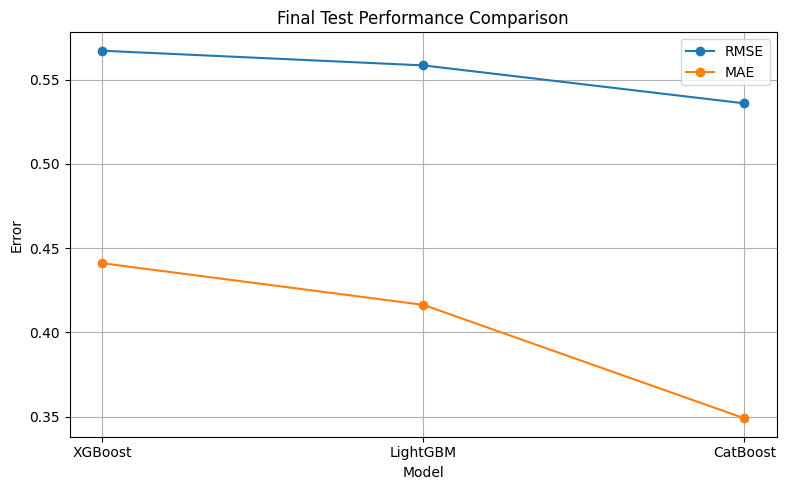

In [125]:
models = ["XGBoost", "LightGBM", "CatBoost"]

rmse = [0.5671, 0.5584, test_rmse]
mae = [0.4411, 0.4164, test_mae]

plt.figure(figsize=(8, 5))

plt.plot(models, rmse, marker='o', label='RMSE')

plt.plot(models, mae, marker='o', label='MAE')

plt.xlabel("Model")
plt.ylabel("Error")
plt.title("Final Test Performance Comparison")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


According to the graph, CatBoost performs the best among 3 models in terms of both metrics, while XGBoost performs the worst.